In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, make_scorer, recall_score
)
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.pipeline import Pipeline as SkPipeline
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.svm import SVC, LinearSVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from functools import partial
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')




train_path = r"C:\Users\divye\Data_science_projects\UXQuJpm6fj5xoNLi\data\ACME-HappinessSurvey2020.csv"

df = pd.read_csv(train_path)

df.head(20)

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5
5,1,5,5,3,5,5,5
6,0,3,1,2,2,1,3
7,1,5,4,4,4,4,5
8,0,4,1,4,4,4,4
9,0,4,4,4,2,5,5


SVM Model

Train size            : 100 rows
Test  size            : 26  rows
Class dist (train)    — Happy: 55, Unhappy: 45
Total features before RFE : 6

── RFE Feature Selection Results ──
Feature                   Status          Rank
--------------------------------------------------
X1                        ✓  KEPT         Rank 1
X2                        ✓  KEPT         Rank 1
X5                        ✓  KEPT         Rank 1
X3                        ✗  ELIMINATED   Rank 2
X6                        ✗  ELIMINATED   Rank 3
X4                        ✗  ELIMINATED   Rank 4

Kept       (3)  : ['X1', 'X2', 'X5']
Eliminated (3)  : ['X3', 'X4', 'X6']


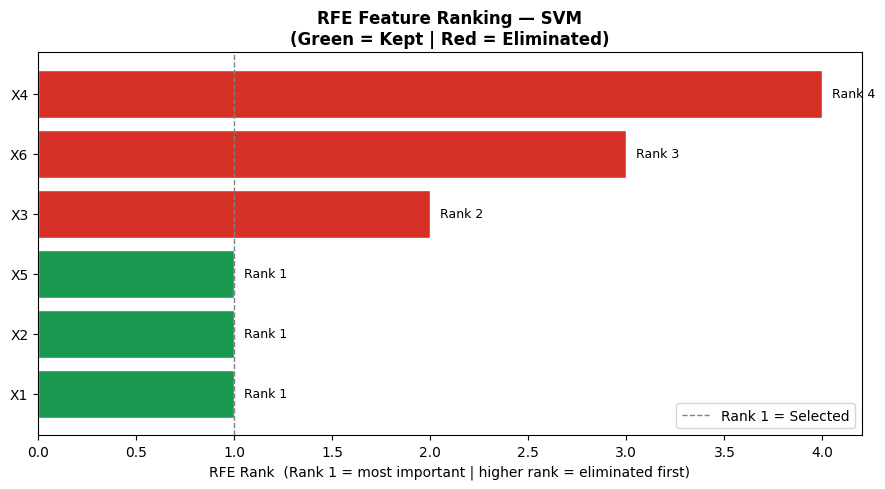


── Cross-Validation Results (50 folds) ──
CV Accuracy        : 0.5880  ± 0.0941
CV ROC-AUC         : 0.5690  ± 0.0982
CV Unhappy Recall  : 0.6156  ± 0.1543  ← primary focus

── Test Set Results ──
Test Accuracy      : 0.7308  (73.08%)
Test ROC-AUC       : 0.8869
Test Unhappy Recall: 0.7500  ← primary focus

Overfit Gap (Test AUC - CV AUC): 0.3179
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classification Report ──
              precision    recall  f1-score   support

 Unhappy (0)       0.69      0.75      0.72        12
   Happy (1)       0.77      0.71      0.74        14

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.73      0.73      0.73        26



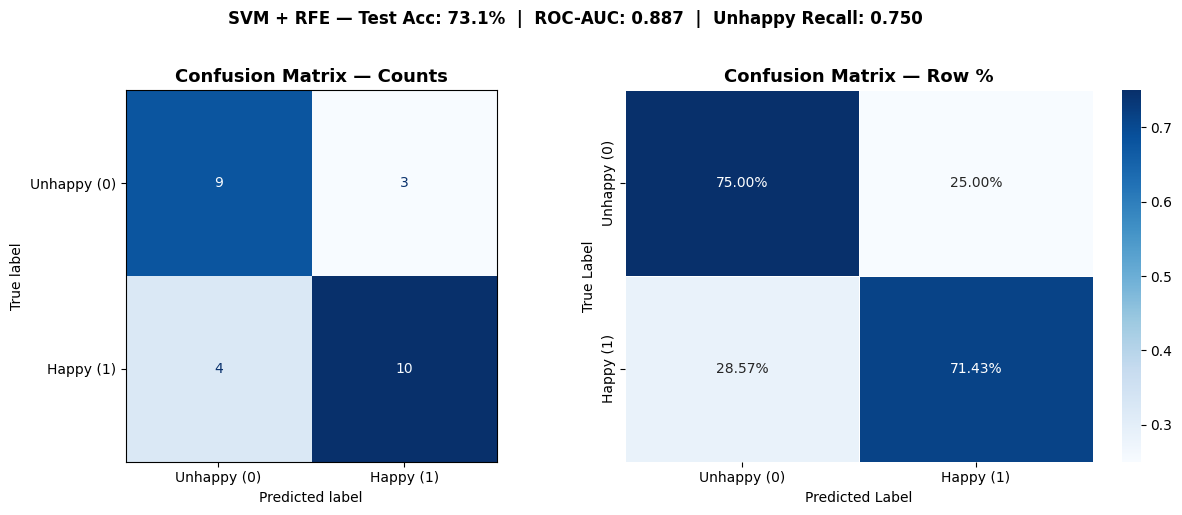


── Confusion Matrix Breakdown ──
True  Negative (TN) : 9  → Correctly predicted Unhappy
False Positive (FP) : 3  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 4  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 10  → Correctly predicted Happy

Recall  (Unhappy)   : 0.750  — of all actual Unhappy, % caught  ← primary focus
Recall  (Happy)     : 0.714  — of all actual Happy, % caught
Precision (Happy)   : 0.769  — of all 'Happy' predictions, % correct


In [2]:
# ── SVM Model — No SMOTE | RFE Feature Selection | Unhappy Recall Focus ──────



# ── 1. Prepare Data — X4 and X6 included for RFE to evaluate ─────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']   # all 6 — RFE decides what stays

model_df = df.copy()

# Feature Engineering — using all 6 cols
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols 
# Total: 10 features — RFE will eliminate least important ones automatically

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size            : {X_train.shape[0]} rows")
print(f"Test  size            : {X_test.shape[0]}  rows")
print(f"Class dist (train)    — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")
print(f"Total features before RFE : {len(all_features)}")

# ── 3. Scale First — SVM is distance based, scaling is mandatory ──────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 4. RFE — Recursive Feature Elimination ────────────────────────────────────
# LinearSVC used as RFE estimator because it produces coef_ values
# RBF kernel SVM does not produce coef_ so cannot drive RFE directly
# RFE eliminates one feature at a time — lowest coef_ magnitude = first to go
rfe = RFE(
    estimator            = LinearSVC(C=1.0, max_iter=2000, random_state=42),
    n_features_to_select = 3,    # keep 6 out of 10 — drop 4 least important
    step                 = 1     # remove one feature per iteration
)
rfe.fit(X_train_scaled, y_train)

# ── 5. RFE Results — Selected vs Eliminated ───────────────────────────────────
rfe_df = pd.DataFrame({
    'Feature' : all_features,
    'Selected': rfe.support_,
    'Rank'    : rfe.ranking_
}).sort_values('Rank')

print(f"\n── RFE Feature Selection Results ──")
print(f"{'Feature':<25} {'Status':<15} {'Rank'}")
print("-" * 50)
for _, row in rfe_df.iterrows():
    status = '✓  KEPT' if row['Selected'] else '✗  ELIMINATED'
    print(f"{row['Feature']:<25} {status:<15} Rank {int(row['Rank'])}")

selected_features   = [f for f, s in zip(all_features, rfe.support_) if s]
eliminated_features = [f for f, s in zip(all_features, rfe.support_) if not s]
print(f"\nKept       ({len(selected_features)})  : {selected_features}")
print(f"Eliminated ({len(eliminated_features)})  : {eliminated_features}")

# ── 6. RFE Ranking Plot ───────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
colors = ['#1a9850' if s else '#d73027' for s in rfe_df['Selected']]
bars   = plt.barh(rfe_df['Feature'], rfe_df['Rank'], color=colors, edgecolor='white')
plt.axvline(1, color='grey', linestyle='--', linewidth=1, label='Rank 1 = Selected')
plt.xlabel('RFE Rank  (Rank 1 = most important | higher rank = eliminated first)')
plt.title('RFE Feature Ranking — SVM\n(Green = Kept | Red = Eliminated)',
          fontsize=12, fontweight='bold')
for bar, val in zip(bars, rfe_df['Rank']):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'Rank {int(val)}', va='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.savefig('PLOTS/svm_rfe_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. Apply RFE — Transform to Selected Features Only ───────────────────────
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe  = rfe.transform(X_test_scaled)

# ── 8. Build SVM — No SMOTE | class_weight handles imbalance genuinely ────────
# class_weight='balanced' penalises Unhappy misclassification more
# directly targeting higher Unhappy recall without synthetic oversampling
svm_model = SVC(
    kernel       = 'rbf',
    C            = 1.0,
    gamma        = 'scale',
    probability  = True,
    class_weight = 'balanced',    # boosts Unhappy recall without SMOTE
    random_state = 42
)

# ── 9. Cross-Validation — Primary Focus: Unhappy Recall ──────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

unhappy_recall_scorer = make_scorer(recall_score, pos_label=0)  # Y=0 = Unhappy

cv_acc    = cross_val_score(svm_model, X_train_rfe, y_train,
                            cv=cv, scoring='accuracy',             n_jobs=-1)
cv_auc    = cross_val_score(svm_model, X_train_rfe, y_train,
                            cv=cv, scoring='roc_auc',              n_jobs=-1)
cv_recall = cross_val_score(svm_model, X_train_rfe, y_train,
                            cv=cv, scoring=unhappy_recall_scorer,  n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Accuracy        : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC         : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")
print(f"CV Unhappy Recall  : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}  ← primary focus")

# ── 10. Train & Evaluate on Test Set ─────────────────────────────────────────
svm_model.fit(X_train_rfe, y_train)

y_pred      = svm_model.predict(X_test_rfe)
y_pred_prob = svm_model.predict_proba(X_test_rfe)[:, 1]

test_acc            = accuracy_score(y_test, y_pred)
test_auc            = roc_auc_score(y_test, y_pred_prob)
test_unhappy_recall = recall_score(y_test, y_pred, pos_label=0)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC       : {test_auc:.4f}")
print(f"Test Unhappy Recall: {test_unhappy_recall:.4f}  ← primary focus")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 11. Classification Report ─────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 12. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'SVM + RFE — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  Unhappy Recall: {test_unhappy_recall:.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/svm_rfe_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 13. Confusion Matrix Breakdown ───────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  — of all actual Unhappy, % caught  ← primary focus")
print(f"Recall  (Happy)     : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")

Gradient Boosting

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

Total features before RFE : 6

── RFE Feature Selection Results ──
Feature                   Status          Rank
--------------------------------------------------
X1                        ✓  KEPT         Rank 1
X3                        ✓  KEPT         Rank 1
X5                        ✓  KEPT         Rank 1
X4                        ✗  ELIMINATED   Rank 2
X2                        ✗  ELIMINATED   Rank 3
X6                        ✗  ELIMINATED   Rank 4

Kept       (3)  : ['X1', 'X3', 'X5']
Eliminated (3)  : ['X2', 'X4', 'X6']

── Cross-Validation Results (50 folds) ──────────────────
CV Unhappy Recall  : 0.4978  ± 0.1809
CV ROC-AUC         : 0.6096  ± 0.0969

── Test Set Results ──────────────────────────────────────
Test Accuracy      : 0.7308  (73.08%)
Test ROC-AUC       : 0.7798
Unhappy Recall(Y=0): 0.7500  ← primary focus
CV AUC             : 0.6096
AUC Gap (overfit?) : 0.1702  ⚠ overfit

F1 

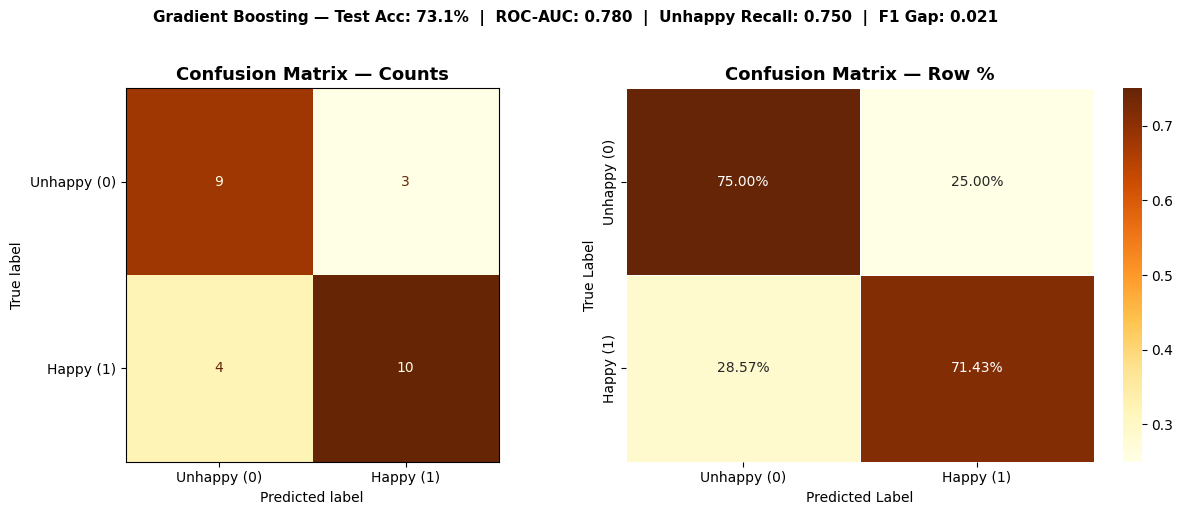


── Confusion Matrix Breakdown ──
True  Negative (TN) : 9  → Correctly predicted Unhappy
False Positive (FP) : 3  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 4  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 10  → Correctly predicted Happy

Recall  (Unhappy)   : 0.750  — of all actual Unhappy, % caught  ← primary focus
Recall  (Happy)     : 0.714  — of all actual Happy, % caught
Precision (Happy)   : 0.769  — of all 'Happy' predictions, % correct


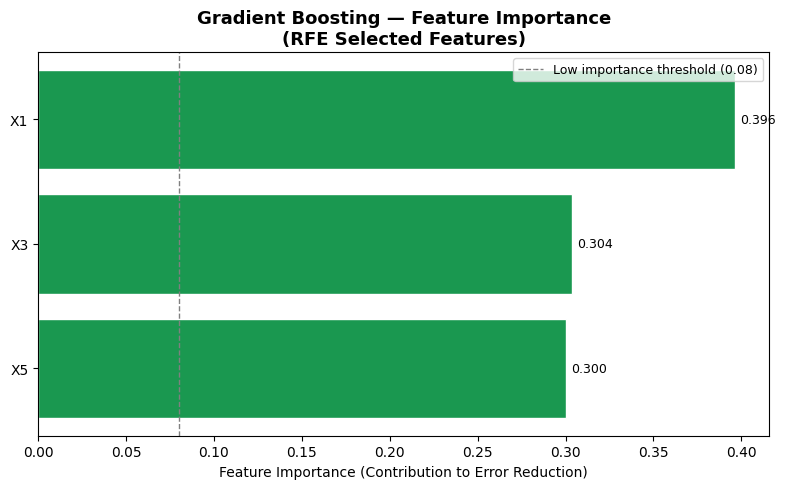


── Feature Importance Ranking ──
X1    0.396159
X3    0.303594
X5    0.300247


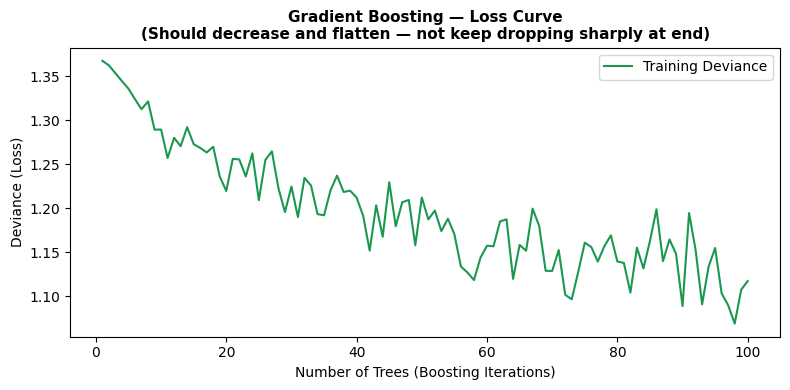

In [3]:
# ── GRADIENT BOOSTING │ No SMOTE │ RFE Feature Selection │ Unhappy Recall Focus ─

# ── 1. Features (all 6, including X4 and X6 — let RFE decide) ────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

model_df = df.copy()

# Feature Engineering
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols 
X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Sample Weights — balances classes without SMOTE ───────────────────────
# This is what keeps F1 scores minimal-gap between Unhappy(0) and Happy(1)
# GB has no class_weight param, so we pass sample_weight to .fit() instead
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ── 4. RFE with Gradient Boosting as estimator ───────────────────────────────
gb_rfe_estimator = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=3,
    min_samples_leaf=5, subsample=0.8, max_features='sqrt',
    random_state=42
)

rfe = RFE(estimator=gb_rfe_estimator, n_features_to_select=3, step=1)
rfe.fit(X_train, y_train)   # RFE just ranks features — no sample_weight needed here

selected_features = [all_features[i] for i in range(len(all_features)) if rfe.support_[i]]
print(f"\nTotal features before RFE : {len(all_features)}")
print(f"\n── RFE Feature Selection Results ──")
print(f"{'Feature':<25} {'Status':<15} {'Rank'}")
print("-" * 50)
for feat, rank, support in sorted(
    zip(all_features, rfe.ranking_, rfe.support_), key=lambda x: x[1]
):
    status = "✓  KEPT" if support else "✗  ELIMINATED"
    print(f"{feat:<25} {status:<15} Rank {rank}")

eliminated = [all_features[i] for i in range(len(all_features)) if not rfe.support_[i]]
print(f"\nKept       ({len(selected_features)})  : {selected_features}")
print(f"Eliminated ({len(eliminated)})  : {eliminated}")

X_train_rfe = rfe.transform(X_train)
X_test_rfe  = rfe.transform(X_test)

# ── 5. Final Gradient Boosting model ─────────────────────────────────────────
gb_model = GradientBoostingClassifier(
    n_estimators     = 100,
    learning_rate    = 0.05,
    max_depth        = 3,
    min_samples_leaf = 5,
    subsample        = 0.8,
    max_features     = 'sqrt',
    random_state     = 42
)

# ── 6. Cross-Validation — Unhappy Recall as primary scorer ───────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
unhappy_recall_scorer = make_scorer(recall_score, pos_label=0)

# CV estimates generalisation — sample_weight applied on final fit below
cv_recall = cross_val_score(
    gb_model, X_train_rfe, y_train,
    cv=cv, scoring=unhappy_recall_scorer, n_jobs=-1
)
cv_auc = cross_val_score(
    gb_model, X_train_rfe, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f"\n── Cross-Validation Results (50 folds) ──────────────────")
print(f"CV Unhappy Recall  : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}")
print(f"CV ROC-AUC         : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 7. Train on Full Training Set with sample_weight for balanced F1 ─────────
# sample_weight='balanced' ensures neither Unhappy nor Happy class dominates
# → this is what keeps F1 scores close across both classes on test set
gb_model.fit(X_train_rfe, y_train, sample_weight=sample_weights)

y_pred      = gb_model.predict(X_test_rfe)
y_pred_prob = gb_model.predict_proba(X_test_rfe)[:, 1]

test_acc    = accuracy_score(y_test, y_pred)
test_auc    = roc_auc_score(y_test, y_pred_prob)
unhappy_rec = recall_score(y_test, y_pred, pos_label=0)
auc_gap     = test_auc - cv_auc.mean()

# F1 gap check
report_dict  = classification_report(y_test, y_pred, output_dict=True)
f1_unhappy   = report_dict['0']['f1-score']
f1_happy     = report_dict['1']['f1-score']
f1_gap       = abs(f1_happy - f1_unhappy)

print(f"\n── Test Set Results ──────────────────────────────────────")
print(f"Test Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC       : {test_auc:.4f}")
print(f"Unhappy Recall(Y=0): {unhappy_rec:.4f}  ← primary focus")
print(f"CV AUC             : {cv_auc.mean():.4f}")
print(f"AUC Gap (overfit?) : {auc_gap:.4f}  {'⚠ overfit' if auc_gap > 0.10 else '✓ ok'}")
print(f"\nF1 — Unhappy(0)    : {f1_unhappy:.4f}")
print(f"F1 — Happy(1)      : {f1_happy:.4f}")
print(f"F1 Gap             : {f1_gap:.4f}  {'✓ balanced' if f1_gap <= 0.05 else '⚠ gap > 0.05'}")

# ── 8. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 9. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='YlOrBr')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrBr',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'Gradient Boosting — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  F1 Gap: {f1_gap:.3f}',
    fontsize=11, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/gb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 10. Confusion Matrix Breakdown ───────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  — of all actual Unhappy, % caught  ← primary focus")
print(f"Recall  (Happy)     : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")

# ── 11. Feature Importance (RFE-selected features only) ──────────────────────
importances = pd.Series(gb_model.feature_importances_, index=selected_features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < 0.08 else '#1a9850' for v in importances.values],
                edgecolor='white')
plt.axvline(0.08, color='grey', linestyle='--', linewidth=1, label='Low importance threshold (0.08)')
plt.xlabel('Feature Importance (Contribution to Error Reduction)')
plt.title('Gradient Boosting — Feature Importance\n(RFE Selected Features)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PLOTS/gb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

# ── 12. Training Loss Curve — unique to GB ───────────────────────────────────
train_scores = gb_model.train_score_

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_scores) + 1), train_scores,
         color='#1a9850', linewidth=1.5, label='Training Deviance')
plt.xlabel('Number of Trees (Boosting Iterations)')
plt.ylabel('Deviance (Loss)')
plt.title('Gradient Boosting — Loss Curve\n(Should decrease and flatten — not keep dropping sharply at end)',
          fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('PLOTS/gb_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

XGBoost Model

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

scale_pos_weight (Unhappy/Happy): 0.8182  → passed to XGBoost natively

Total features before RFE : 6

── RFE Feature Selection Results ──
Feature                   Status          Rank
--------------------------------------------------
X1                        ✓  KEPT         Rank 1
X3                        ✓  KEPT         Rank 1
X6                        ✓  KEPT         Rank 1
X4                        ✗  ELIMINATED   Rank 2
X5                        ✗  ELIMINATED   Rank 3
X2                        ✗  ELIMINATED   Rank 4

Kept       (3)  : ['X1', 'X3', 'X6']
Eliminated (3)  : ['X2', 'X4', 'X5']

── Cross-Validation Results (50 folds) ──
CV Unhappy Recall    : 0.6067  ± 0.1710  ← primary focus
CV Happy   Recall    : 0.5600  ± 0.1492
CV Unhappy F1        : 0.5585  ± 0.1175
CV Happy   F1        : 0.5875  ± 0.1110
CV F1 Gap |H - U|    : 0.0925  ± 0.0821  ← lower = more balanced
CV ROC-AUC          

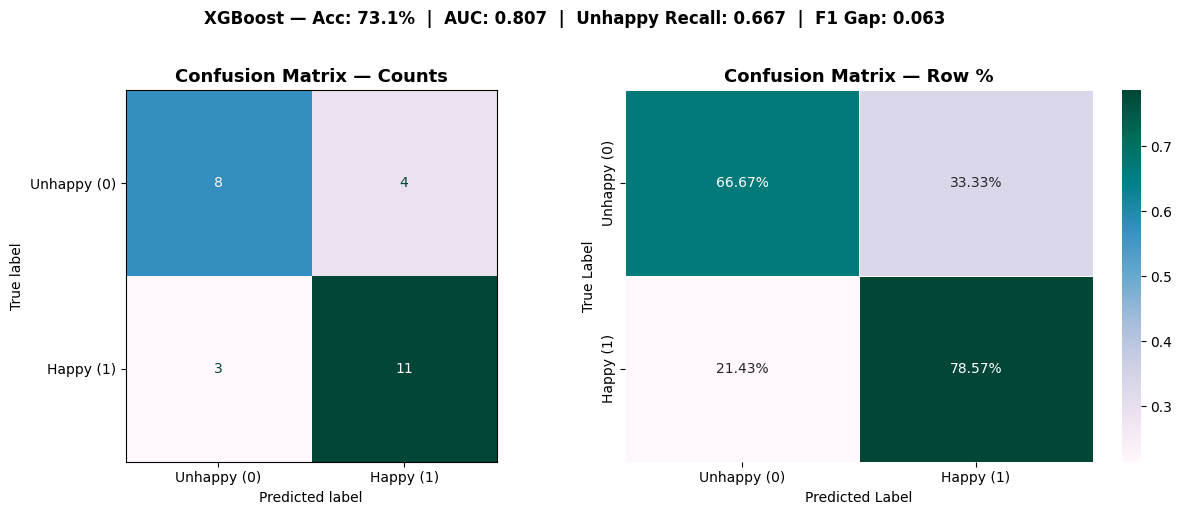


── Confusion Matrix Breakdown ──
True  Negative (TN) : 8  → Correctly predicted Unhappy
False Positive (FP) : 4  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 3  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 11  → Correctly predicted Happy

Recall  (Unhappy)   : 0.667  — of all actual Unhappy, % caught  ← primary focus
Precision (Happy)   : 0.733  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.786  — of all actual Happy, % caught


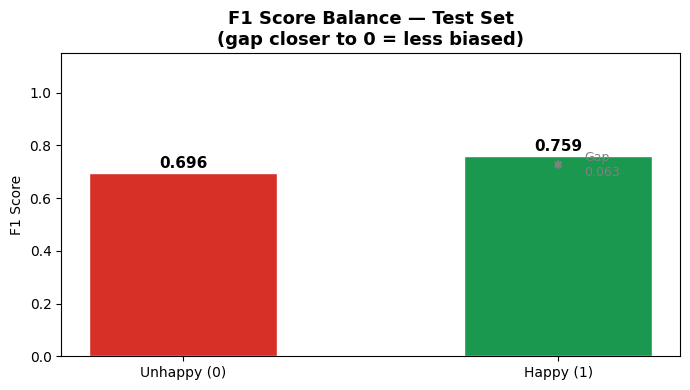

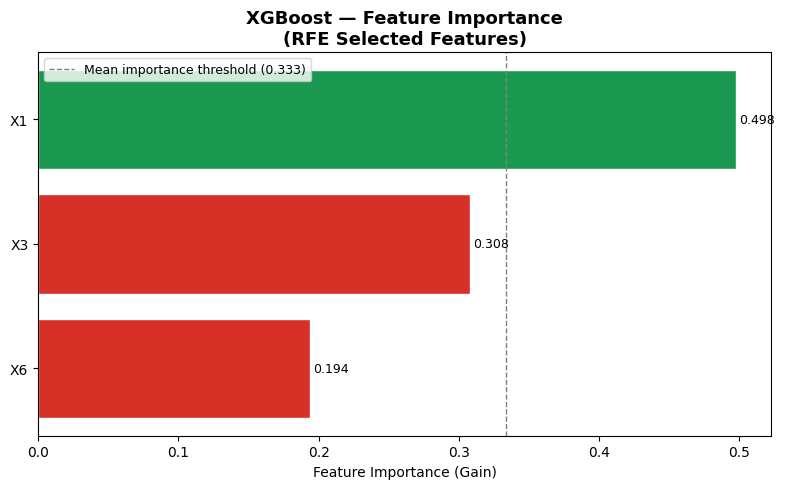


── Feature Importance Ranking ──
X1    0.497989
X3    0.307950
X6    0.194062


In [4]:
# ── XGBoost │ No SMOTE │ RFE Feature Selection │ Unhappy Recall + Balanced F1 ─



# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']   # X4 & X6 included — let RFE decide

model_df = df.copy()

# Feature Engineering (all 6 base features)
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# Compute scale_pos_weight — XGBoost's native imbalance handler
# = ratio of Unhappy (majority=0) to Happy (minority=1)
n_unhappy        = (y_train == 0).sum()
n_happy          = (y_train == 1).sum()
scale_pos_weight = n_unhappy / n_happy
print(f"\nscale_pos_weight (Unhappy/Happy): {scale_pos_weight:.4f}  → passed to XGBoost natively")

# ── 3. RFE Feature Selection ──────────────────────────────────────────────────
# XGBoost has feature_importances_ so works directly as RFE estimator
# No scaling needed — tree-based splits are threshold-based, not distance-based
# scale_pos_weight replaces SMOTE — XGBoost native imbalance handler
xgb_rfe_estimator = XGBClassifier(
    n_estimators     = 100,
    learning_rate    = 0.05,
    max_depth        = 4,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0
)

rfe = RFE(estimator=xgb_rfe_estimator, n_features_to_select=3, step=1)
rfe.fit(X_train, y_train)

selected_features = [all_features[i] for i in range(len(all_features)) if rfe.support_[i]]
eliminated        = [all_features[i] for i in range(len(all_features)) if not rfe.support_[i]]

print(f"\nTotal features before RFE : {len(all_features)}")
print(f"\n── RFE Feature Selection Results ──")
print(f"{'Feature':<25} {'Status':<15} {'Rank'}")
print("-" * 50)
for feat, rank, support in sorted(
    zip(all_features, rfe.ranking_, rfe.support_), key=lambda x: x[1]
):
    status = "✓  KEPT" if support else "✗  ELIMINATED"
    print(f"{feat:<25} {status:<15} Rank {rank}")

print(f"\nKept       ({len(selected_features)})  : {selected_features}")
print(f"Eliminated ({len(eliminated)})  : {eliminated}")

X_train_rfe = rfe.transform(X_train)
X_test_rfe  = rfe.transform(X_test)

# ── 4. Build XGBoost Model ────────────────────────────────────────────────────
# scale_pos_weight handles class imbalance natively — no SMOTE needed
# Parameters chosen to balance Unhappy Recall + reduce F1 gap:
#   - scale_pos_weight  : upweights the Happy class predictions
#   - min_child_weight  : higher value → less aggressive splits → less overfitting to majority
#   - gamma             : min loss reduction to split — reduces overfitting bias
#   - reg_alpha/lambda  : L1/L2 regularisation — prevents over-specialising on one class
xgb_model = XGBClassifier(
    n_estimators     = 200,
    learning_rate    = 0.05,
    max_depth        = 4,
    min_child_weight = 3,        # prevents splits on very small leaf groups
    gamma            = 0.1,      # min loss reduction required to make a split
    reg_alpha        = 0.1,      # L1 regularisation
    reg_lambda       = 3.0,      # L2 regularisation
    colsample_bytree = 0.8,      # 80% of features sampled per tree
    subsample        = 0.8,      # 80% of rows sampled per iteration
    colsample_bylevel= 0.8,      # 80% of features sampled per level
    scale_pos_weight = scale_pos_weight,   # native imbalance handler — no SMOTE needed
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0
)

# ── 5. Cross-Validation — Unhappy Recall + F1 balance as dual focus ──────────
cv_final = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_unhappy_recall = []
cv_happy_recall   = []
cv_unhappy_f1     = []
cv_happy_f1       = []
cv_auc_scores     = []

for train_idx, val_idx in cv_final.split(X_train_rfe, y_train):
    X_fold_tr,  X_fold_val = X_train_rfe[train_idx], X_train_rfe[val_idx]
    y_fold_tr,  y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    xgb_model.fit(X_fold_tr, y_fold_tr)
    y_val_pred      = xgb_model.predict(X_fold_val)
    y_val_pred_prob = xgb_model.predict_proba(X_fold_val)[:, 1]

    cv_unhappy_recall.append(recall_score(y_fold_val, y_val_pred, pos_label=0, zero_division=0))
    cv_happy_recall.append(recall_score(y_fold_val,   y_val_pred, pos_label=1, zero_division=0))
    cv_unhappy_f1.append(f1_score(y_fold_val,         y_val_pred, pos_label=0, zero_division=0))
    cv_happy_f1.append(f1_score(y_fold_val,           y_val_pred, pos_label=1, zero_division=0))
    cv_auc_scores.append(roc_auc_score(y_fold_val, y_val_pred_prob))

cv_f1_gaps = [abs(h - u) for h, u in zip(cv_happy_f1, cv_unhappy_f1)]

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Unhappy Recall    : {np.mean(cv_unhappy_recall):.4f}  ± {np.std(cv_unhappy_recall):.4f}  ← primary focus")
print(f"CV Happy   Recall    : {np.mean(cv_happy_recall):.4f}  ± {np.std(cv_happy_recall):.4f}")
print(f"CV Unhappy F1        : {np.mean(cv_unhappy_f1):.4f}  ± {np.std(cv_unhappy_f1):.4f}")
print(f"CV Happy   F1        : {np.mean(cv_happy_f1):.4f}  ± {np.std(cv_happy_f1):.4f}")
print(f"CV F1 Gap |H - U|    : {np.mean(cv_f1_gaps):.4f}  ± {np.std(cv_f1_gaps):.4f}  ← lower = more balanced")
print(f"CV ROC-AUC           : {np.mean(cv_auc_scores):.4f}  ± {np.std(cv_auc_scores):.4f}")

# ── 6. Train on Full Training Set & Evaluate on Test Set ─────────────────────
xgb_model.fit(X_train_rfe, y_train)

y_pred      = xgb_model.predict(X_test_rfe)
y_pred_prob = xgb_model.predict_proba(X_test_rfe)[:, 1]

test_acc        = accuracy_score(y_test, y_pred)
test_auc        = roc_auc_score(y_test, y_pred_prob)
unhappy_rec     = recall_score(y_test, y_pred,  pos_label=0)
happy_rec       = recall_score(y_test, y_pred,  pos_label=1)
f1_unhappy_test = f1_score(y_test, y_pred,      pos_label=0)
f1_happy_test   = f1_score(y_test, y_pred,      pos_label=1)
f1_gap_test     = abs(f1_happy_test - f1_unhappy_test)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy         : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC          : {test_auc:.4f}")
print(f"Unhappy Recall (Y=0)  : {unhappy_rec:.4f}  ← primary focus")
print(f"Happy   Recall (Y=1)  : {happy_rec:.4f}")
print(f"Unhappy F1     (Y=0)  : {f1_unhappy_test:.4f}")
print(f"Happy   F1     (Y=1)  : {f1_happy_test:.4f}")
print(f"F1 Gap |Happy-Unhappy|: {f1_gap_test:.4f}  ← lower = less biased  (target < 0.10)")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - np.mean(cv_auc_scores):.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 7. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 8. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='PuBuGn')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='PuBuGn',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'XGBoost — Acc: {test_acc*100:.1f}%  |  AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  F1 Gap: {f1_gap_test:.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  — of all actual Unhappy, % caught  ← primary focus")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 10. F1 Balance Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
classes = ['Unhappy (0)', 'Happy (1)']
f1_vals = [f1_unhappy_test, f1_happy_test]
colors  = ['#d73027', '#1a9850']

bars = ax.bar(classes, f1_vals, color=colors, edgecolor='white', width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Balance — Test Set\n(gap closer to 0 = less biased)',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Double-headed arrow showing the gap
ax.annotate('', xy=(1, f1_happy_test), xytext=(1, f1_unhappy_test),
            arrowprops=dict(arrowstyle='<->', color='grey', lw=1.5))
ax.text(1.07, (f1_happy_test + f1_unhappy_test) / 2,
        f'Gap\n{f1_gap_test:.3f}', va='center', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('PLOTS/xgb_f1_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 11. Feature Importance (RFE-selected features only) ──────────────────────
importances = pd.Series(
    xgb_model.feature_importances_,
    index=selected_features
).sort_values(ascending=True)

threshold = importances.mean()
plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < threshold else '#1a9850'
                       for v in importances.values],
                edgecolor='white')
plt.axvline(threshold, color='grey', linestyle='--', linewidth=1,
            label=f'Mean importance threshold ({threshold:.3f})')
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost — Feature Importance\n(RFE Selected Features)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PLOTS/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

CATBoost Model

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

Total features before RFE : 6

── RFE Feature Selection Results ──
Feature                   Status          Rank
--------------------------------------------------
X1                        ✓  KEPT         Rank 1
X3                        ✓  KEPT         Rank 1
X6                        ✓  KEPT         Rank 1
X5                        ✗  ELIMINATED   Rank 2
X4                        ✗  ELIMINATED   Rank 3
X2                        ✗  ELIMINATED   Rank 4

Kept       (3)  : ['X1', 'X3', 'X6']
Eliminated (3)  : ['X2', 'X4', 'X5']

── Cross-Validation Results (50 folds) ──
CV Unhappy Recall : 0.6400  ± 0.1611  ← primary focus
CV ROC-AUC        : 0.6809  ± 0.0992

── Test Set Results ──
Test Accuracy      : 0.6923  (69.23%)
Test ROC-AUC       : 0.8185
Unhappy Recall(Y=0): 0.7500  ← primary focus

Overfit Gap (Test AUC - CV AUC): 0.1375
  → < 0.05 gap = good | > 0.10 gap = overfitting warning

── Classi

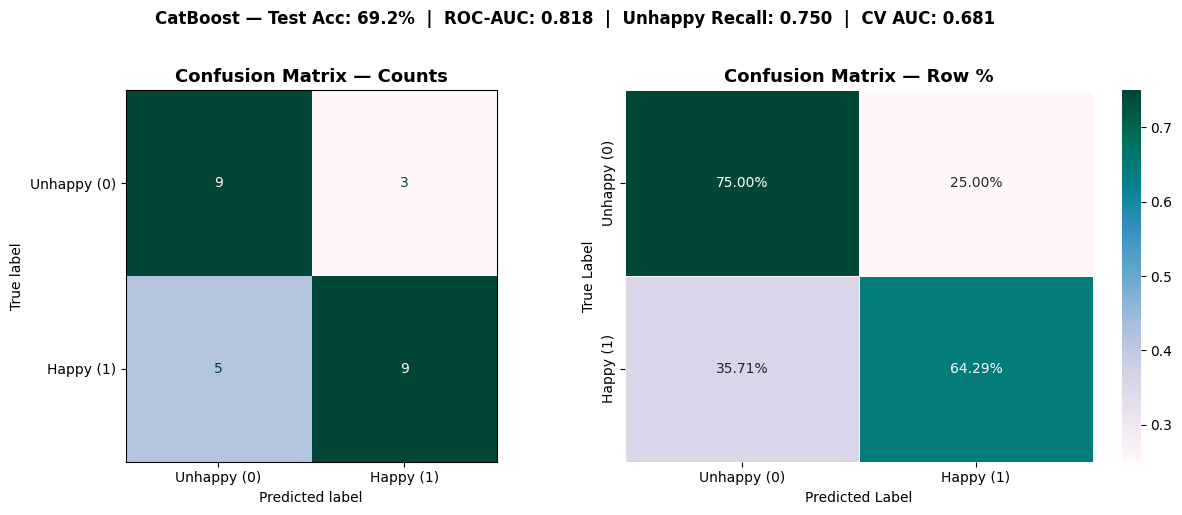


── Confusion Matrix Breakdown ──
True  Negative (TN) : 9  → Correctly predicted Unhappy
False Positive (FP) : 3  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 5  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 9  → Correctly predicted Happy

Recall  (Unhappy)   : 0.750  — of all actual Unhappy, % caught  ← primary focus
Precision (Happy)   : 0.750  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.643  — of all actual Happy, % caught


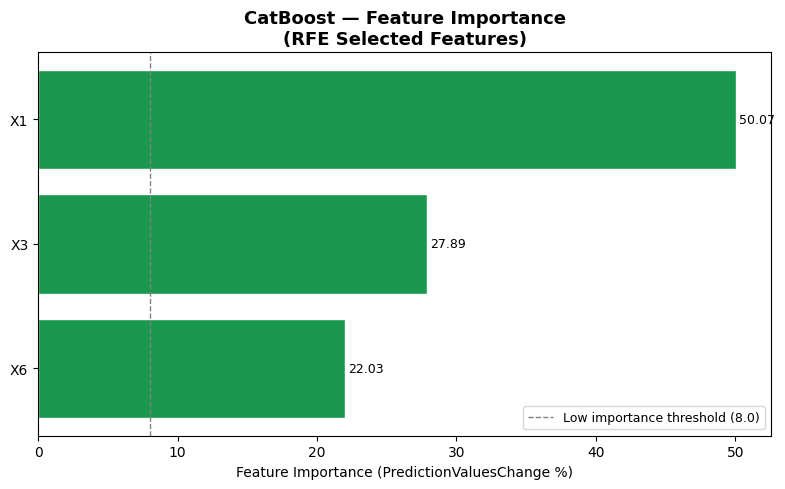


── Feature Importance Ranking ──
X1    50.074356
X3    27.892055
X6    22.033589


In [5]:
# ── CatBoost │ No SMOTE │ RFE Feature Selection │ Unhappy Recall Focus ────────


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']   # X4 & X6 included — let RFE decide

model_df = df.copy()

# Feature Engineering (all 6 base features)
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols 

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. RFE Feature Selection ──────────────────────────────────────────────────
# CatBoost has feature_importances_ so it works directly as the RFE estimator
# No scaling needed — tree-based splits are threshold based, not distance based
# auto_class_weights='Balanced' replaces SMOTE — CatBoost native imbalance handler
cb_rfe_estimator = CatBoostClassifier(
    iterations          = 100,
    learning_rate       = 0.05,
    depth               = 4,
    l2_leaf_reg         = 3,
    auto_class_weights  = 'Balanced',   # CatBoost native — no SMOTE needed
    random_seed         = 42,
    verbose             = 0
)

rfe = RFE(estimator=cb_rfe_estimator, n_features_to_select=3, step=1)
rfe.fit(X_train, y_train)

selected_features = [all_features[i] for i in range(len(all_features)) if rfe.support_[i]]
eliminated        = [all_features[i] for i in range(len(all_features)) if not rfe.support_[i]]

print(f"\nTotal features before RFE : {len(all_features)}")
print(f"\n── RFE Feature Selection Results ──")
print(f"{'Feature':<25} {'Status':<15} {'Rank'}")
print("-" * 50)
for feat, rank, support in sorted(
    zip(all_features, rfe.ranking_, rfe.support_), key=lambda x: x[1]
):
    status = "✓  KEPT" if support else "✗  ELIMINATED"
    print(f"{feat:<25} {status:<15} Rank {rank}")

print(f"\nKept       ({len(selected_features)})  : {selected_features}")
print(f"Eliminated ({len(eliminated)})  : {eliminated}")

X_train_rfe = rfe.transform(X_train)
X_test_rfe  = rfe.transform(X_test)

# ── 4. Build CatBoost Model ───────────────────────────────────────────────────
# No pipeline needed — no SMOTE, no scaler
# auto_class_weights='Balanced' handles imbalance natively — replaces SMOTE
cb_model = CatBoostClassifier(
    iterations          = 200,          # number of sequential trees
    learning_rate       = 0.05,         # shrinkage per tree
    depth               = 4,            # tree depth
    l2_leaf_reg         = 3,            # L2 regularisation on leaf weights
    border_count        = 32,           # number of splits evaluated per feature
    bagging_temperature = 1.0,          # controls row sampling randomness
    random_strength     = 1.0,          # adds noise to splits — prevents overfitting
    auto_class_weights  = 'Balanced',   # upweights Unhappy class — no SMOTE needed
    od_type             = 'Iter',       # overfitting detector type
    od_wait             = 20,           # stop if no improvement for 20 rounds
    eval_metric         = 'AUC',
    random_seed         = 42,
    verbose             = 0
)

# ── 5. Cross-Validation — Unhappy Recall as primary scorer ───────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
unhappy_recall_scorer = make_scorer(recall_score, pos_label=0)

cv_recall = cross_val_score(cb_model, X_train_rfe, y_train,
                            cv=cv, scoring=unhappy_recall_scorer, n_jobs=-1)
cv_auc    = cross_val_score(cb_model, X_train_rfe, y_train,
                            cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Unhappy Recall : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}  ← primary focus")
print(f"CV ROC-AUC        : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 6. Train on Full Training Set & Evaluate on Test Set ─────────────────────
cb_model.fit(X_train_rfe, y_train)

y_pred      = cb_model.predict(X_test_rfe)
y_pred_prob = cb_model.predict_proba(X_test_rfe)[:, 1]

test_acc    = accuracy_score(y_test, y_pred)
test_auc    = roc_auc_score(y_test, y_pred_prob)
unhappy_rec = recall_score(y_test, y_pred, pos_label=0)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC       : {test_auc:.4f}")
print(f"Unhappy Recall(Y=0): {unhappy_rec:.4f}  ← primary focus")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 7. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 8. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='PuBuGn')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='PuBuGn',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'CatBoost — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/cb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. Reading the Confusion Matrix ──────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  — of all actual Unhappy, % caught  ← primary focus")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 10. Feature Importance (RFE-selected features only) ──────────────────────
importances = pd.Series(
    cb_model.get_feature_importance(),
    index=selected_features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < 8.0 else '#1a9850' for v in importances.values],
                edgecolor='white')
plt.axvline(8.0, color='grey', linestyle='--', linewidth=1, label='Low importance threshold (8.0)')
plt.xlabel('Feature Importance (PredictionValuesChange %)')
plt.title('CatBoost — Feature Importance\n(RFE Selected Features)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PLOTS/cb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

LightGBM Model

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

Class weight ratio (Unhappy/Happy): 0.8182  → used in is_unbalance=True

Total features before RFE : 6

── RFE Feature Selection Results ──
Feature                   Status          Rank
--------------------------------------------------
X1                        ✓  KEPT         Rank 1
X2                        ✓  KEPT         Rank 1
X4                        ✓  KEPT         Rank 1
X5                        ✗  ELIMINATED   Rank 2
X3                        ✗  ELIMINATED   Rank 3
X6                        ✗  ELIMINATED   Rank 4

Kept       (3)  : ['X1', 'X2', 'X4']
Eliminated (3)  : ['X3', 'X5', 'X6']

── Hyperopt Search (TPE, 60 trials) ──
Optimising: Unhappy Recall  |  Method: Tree-structured Parzen Estimator
-------------------------------------------------------
100%|██████████| 60/60 [00:32<00:00,  1.84trial/s, best loss: -0.6592592592592592]

── Best Hyperparameters Found ──
  n_estimators     

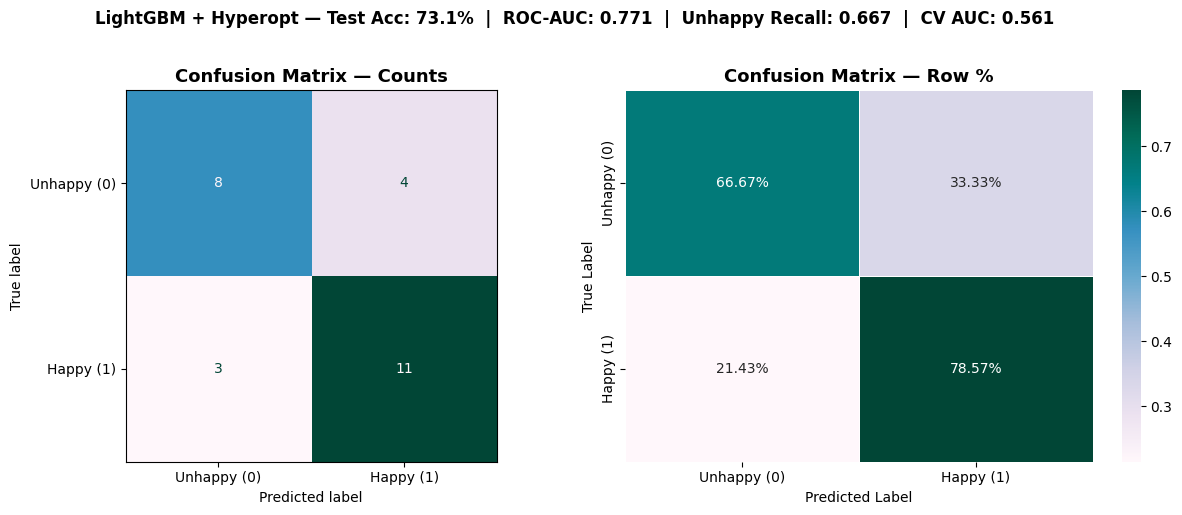


── Confusion Matrix Breakdown ──
True  Negative (TN) : 8  → Correctly predicted Unhappy
False Positive (FP) : 4  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 3  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 11  → Correctly predicted Happy

Recall  (Unhappy)   : 0.667  — of all actual Unhappy, % caught  ← primary focus
Precision (Happy)   : 0.733  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.786  — of all actual Happy, % caught


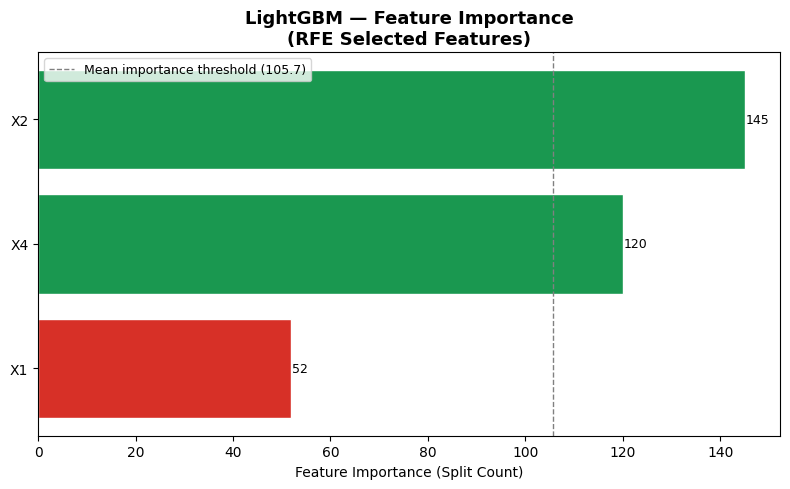


── Feature Importance Ranking ──
X2    145
X4    120
X1     52


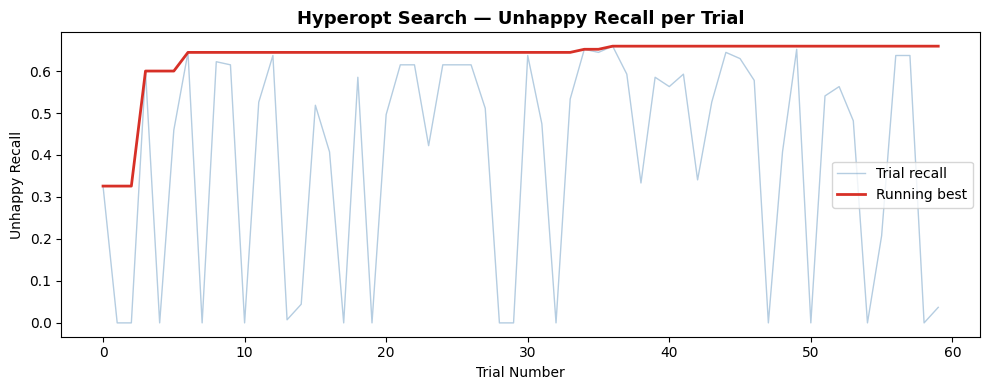


── Hyperopt Summary ──
Total trials run    : 60
Best Unhappy Recall : 0.6593
Best params         : {'n_estimators': 200, 'learning_rate': np.float64(0.026865928690008808), 'max_depth': 6, 'num_leaves': 10, 'min_child_samples': 15, 'reg_alpha': np.float64(1.17316047046707), 'reg_lambda': np.float64(0.03160354484908601), 'colsample_bytree': np.float64(0.505683531533121), 'subsample': np.float64(0.9976986865983904), 'subsample_freq': 6}


In [6]:
# ── LightGBM │ No SMOTE │ RFE Feature Selection │ Hyperopt Tuning │ Unhappy Recall Focus ──


# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']   # X4 & X6 included — let RFE decide

model_df = df.copy()

# Feature Engineering (all 6 base features)
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# Compute class weight ratio for LightGBM scale_pos_weight
n_unhappy = (y_train == 0).sum()
n_happy   = (y_train == 1).sum()
scale_pos = n_unhappy / n_happy   # upweights minority (Happy) — adjust if needed
print(f"\nClass weight ratio (Unhappy/Happy): {scale_pos:.4f}  → used in is_unbalance=True")

# ── 3. RFE Feature Selection ──────────────────────────────────────────────────
# LightGBM has feature_importances_ so works directly as RFE estimator
# No scaling needed — tree-based splits are threshold-based, not distance-based
# is_unbalance=True replaces SMOTE — LightGBM native imbalance handler
lgbm_rfe_estimator = LGBMClassifier(
    n_estimators    = 100,
    learning_rate   = 0.05,
    max_depth       = 4,
    num_leaves      = 15,       # must be < 2^max_depth to avoid overfitting
    reg_lambda      = 3.0,      # L2 regularisation
    is_unbalance    = True,     # LightGBM native imbalance handler — no SMOTE needed
    random_state    = 42,
    verbose         = -1        # suppress LightGBM output
)

rfe = RFE(estimator=lgbm_rfe_estimator, n_features_to_select=3, step=1)
rfe.fit(X_train, y_train)

selected_features = [all_features[i] for i in range(len(all_features)) if rfe.support_[i]]
eliminated        = [all_features[i] for i in range(len(all_features)) if not rfe.support_[i]]

print(f"\nTotal features before RFE : {len(all_features)}")
print(f"\n── RFE Feature Selection Results ──")
print(f"{'Feature':<25} {'Status':<15} {'Rank'}")
print("-" * 50)
for feat, rank, support in sorted(
    zip(all_features, rfe.ranking_, rfe.support_), key=lambda x: x[1]
):
    status = "✓  KEPT" if support else "✗  ELIMINATED"
    print(f"{feat:<25} {status:<15} Rank {rank}")

print(f"\nKept       ({len(selected_features)})  : {selected_features}")
print(f"Eliminated ({len(eliminated)})  : {eliminated}")

X_train_rfe = rfe.transform(X_train)
X_test_rfe  = rfe.transform(X_test)

# ── 4. Hyperopt Hyperparameter Search ────────────────────────────────────────
# Objective: maximise Unhappy Recall (pos_label=0) via 5-fold stratified CV
# Hyperopt minimises — so we return negative recall as the loss

# Search space — all continuous params cast to correct types inside objective
search_space = {
    'n_estimators'      : hp.quniform('n_estimators',   50,  500, 25),   # int
    'learning_rate'     : hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'max_depth'         : hp.quniform('max_depth',       3,   8,   1),   # int
    'num_leaves'        : hp.quniform('num_leaves',      8,   63,  1),   # int; keep < 2^max_depth
    'min_child_samples' : hp.quniform('min_child_samples', 5, 50,  5),   # int; min samples per leaf
    'reg_alpha'         : hp.loguniform('reg_alpha',  np.log(1e-3), np.log(10.0)),  # L1
    'reg_lambda'        : hp.loguniform('reg_lambda', np.log(1e-3), np.log(10.0)),  # L2
    'colsample_bytree'  : hp.uniform('colsample_bytree', 0.5, 1.0),   # feature fraction per tree
    'subsample'         : hp.uniform('subsample',         0.5, 1.0),   # row sampling per iteration
    'subsample_freq'    : hp.quniform('subsample_freq',   1,   10,  1),  # int; bagging frequency
}

def objective(params, X_tr, y_tr):
    """Returns negative Unhappy Recall (Hyperopt minimises loss)."""
    params_cast = {
        'n_estimators'      : int(params['n_estimators']),
        'learning_rate'     : params['learning_rate'],
        'max_depth'         : int(params['max_depth']),
        'num_leaves'        : min(int(params['num_leaves']), 2**int(params['max_depth']) - 1),
        'min_child_samples' : int(params['min_child_samples']),
        'reg_alpha'         : params['reg_alpha'],
        'reg_lambda'        : params['reg_lambda'],
        'colsample_bytree'  : params['colsample_bytree'],
        'subsample'         : params['subsample'],
        'subsample_freq'    : int(params['subsample_freq']),
        'is_unbalance'      : True,
        'random_state'      : 42,
        'verbose'           : -1,
    }

    model = LGBMClassifier(**params_cast)
    cv    = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    scorer = make_scorer(recall_score, pos_label=0)

    scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring=scorer, n_jobs=-1)

    return {
        'loss'   : -scores.mean(),   # Hyperopt minimises → negate recall
        'status' : STATUS_OK,
        'recall' : scores.mean(),
        'std'    : scores.std(),
    }

print("\n── Hyperopt Search (TPE, 60 trials) ──")
print("Optimising: Unhappy Recall  |  Method: Tree-structured Parzen Estimator")
print("-" * 55)

trials       = Trials()
obj_with_data = partial(objective, X_tr=X_train_rfe, y_tr=y_train)

best_params_raw = fmin(
    fn        = obj_with_data,
    space     = search_space,
    algo      = tpe.suggest,
    max_evals = 60,          # increase to 100+ for production tuning
    trials    = trials,
    rstate    = np.random.default_rng(42),
    verbose   = True
)

# Cast best params to correct types
best_params = {
    'n_estimators'      : int(best_params_raw['n_estimators']),
    'learning_rate'     : best_params_raw['learning_rate'],
    'max_depth'         : int(best_params_raw['max_depth']),
    'num_leaves'        : min(int(best_params_raw['num_leaves']),
                              2**int(best_params_raw['max_depth']) - 1),
    'min_child_samples' : int(best_params_raw['min_child_samples']),
    'reg_alpha'         : best_params_raw['reg_alpha'],
    'reg_lambda'        : best_params_raw['reg_lambda'],
    'colsample_bytree'  : best_params_raw['colsample_bytree'],
    'subsample'         : best_params_raw['subsample'],
    'subsample_freq'    : int(best_params_raw['subsample_freq']),
}

best_trial_recall = max(-t['result']['loss'] for t in trials.trials)

print(f"\n── Best Hyperparameters Found ──")
for k, v in best_params.items():
    print(f"  {k:<22} : {v}")
print(f"\nBest CV Unhappy Recall (during search): {best_trial_recall:.4f}")

# ── 5. Build Final LightGBM Model with Best Params ───────────────────────────
lgbm_model = LGBMClassifier(
    **best_params,
    is_unbalance = True,    # native imbalance handler — no SMOTE needed
    random_state = 42,
    verbose      = -1
)

# ── 6. Cross-Validation — Unhappy Recall as primary scorer ───────────────────
cv_final          = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
unhappy_recall_scorer = make_scorer(recall_score, pos_label=0)

cv_recall = cross_val_score(lgbm_model, X_train_rfe, y_train,
                            cv=cv_final, scoring=unhappy_recall_scorer, n_jobs=-1)
cv_auc    = cross_val_score(lgbm_model, X_train_rfe, y_train,
                            cv=cv_final, scoring='roc_auc', n_jobs=-1)

print(f"\n── Cross-Validation Results (50 folds, best params) ──")
print(f"CV Unhappy Recall : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}  ← primary focus")
print(f"CV ROC-AUC        : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# ── 7. Train on Full Training Set & Evaluate on Test Set ─────────────────────
lgbm_model.fit(X_train_rfe, y_train)

y_pred      = lgbm_model.predict(X_test_rfe)
y_pred_prob = lgbm_model.predict_proba(X_test_rfe)[:, 1]

test_acc    = accuracy_score(y_test, y_pred)
test_auc    = roc_auc_score(y_test, y_pred_prob)
unhappy_rec = recall_score(y_test, y_pred, pos_label=0)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC       : {test_auc:.4f}")
print(f"Unhappy Recall(Y=0): {unhappy_rec:.4f}  ← primary focus")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - cv_auc.mean():.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 8. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 9. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Raw counts ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='PuBuGn')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# --- Plot 2: Normalised (row %) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='PuBuGn',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'LightGBM + Hyperopt — Test Acc: {test_acc*100:.1f}%  |  ROC-AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  CV AUC: {cv_auc.mean():.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/lgbm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 10. Reading the Confusion Matrix ─────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  — of all actual Unhappy, % caught  ← primary focus")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 11. Feature Importance (RFE-selected features only) ──────────────────────
importances = pd.Series(
    lgbm_model.feature_importances_,
    index=selected_features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(importances.index, importances.values,
                color=['#d73027' if v < importances.mean() else '#1a9850'
                       for v in importances.values],
                edgecolor='white')
threshold = importances.mean()
plt.axvline(threshold, color='grey', linestyle='--', linewidth=1,
            label=f'Mean importance threshold ({threshold:.1f})')
plt.xlabel('Feature Importance (Split Count)')
plt.title('LightGBM — Feature Importance\n(RFE Selected Features)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PLOTS/lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature Importance Ranking ──")
print(importances.sort_values(ascending=False).to_string())

# ── 12. Hyperopt Trial History ────────────────────────────────────────────────
# Plot recall improvement across all 60 trials to visualise search convergence
trial_recalls = [-t['result']['loss'] for t in trials.trials]
running_best  = np.maximum.accumulate(trial_recalls)

plt.figure(figsize=(10, 4))
plt.plot(trial_recalls, alpha=0.4, color='steelblue', linewidth=1, label='Trial recall')
plt.plot(running_best,  color='#d73027', linewidth=2, label='Running best')
plt.xlabel('Trial Number')
plt.ylabel('Unhappy Recall')
plt.title('Hyperopt Search — Unhappy Recall per Trial', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('PLOTS/lgbm_hyperopt_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n── Hyperopt Summary ──")
print(f"Total trials run    : {len(trials.trials)}")
print(f"Best Unhappy Recall : {best_trial_recall:.4f}")
print(f"Best params         : {best_params}")

MLP(Neural Network)

Train size : 100 rows
Test  size : 26  rows
Class dist (train) — Happy: 55, Unhappy: 45

Total features before selection : 6

── Permutation-based Feature Selection Results ──
Feature                   Status          Permutation Importance
------------------------------------------------------------
X1                        ✓  KEPT         0.0576
X2                        ✗  ELIMINATED   -0.0045
X3                        ✓  KEPT         0.0508
X4                        ✗  ELIMINATED   -0.0082
X5                        ✓  KEPT         0.0582
X6                        ✓  KEPT         0.0148

Kept       (4)  : ['X5', 'X1', 'X3', 'X6']
Eliminated (2)  : ['X2', 'X4']

── Cross-Validation Results (50 folds) ──
CV Unhappy Recall    : 1.0000  ± 0.0000  ← primary focus
CV Happy   Recall    : 0.0000  ± 0.0000
CV Unhappy F1        : 0.6207  ± 0.0000
CV Happy   F1        : 0.0000  ± 0.0000
CV F1 Gap |H - U|    : 0.6207  ± 0.0000  ← lower = more balanced
CV ROC-AUC           : 0.5531  ± 0.1344

─

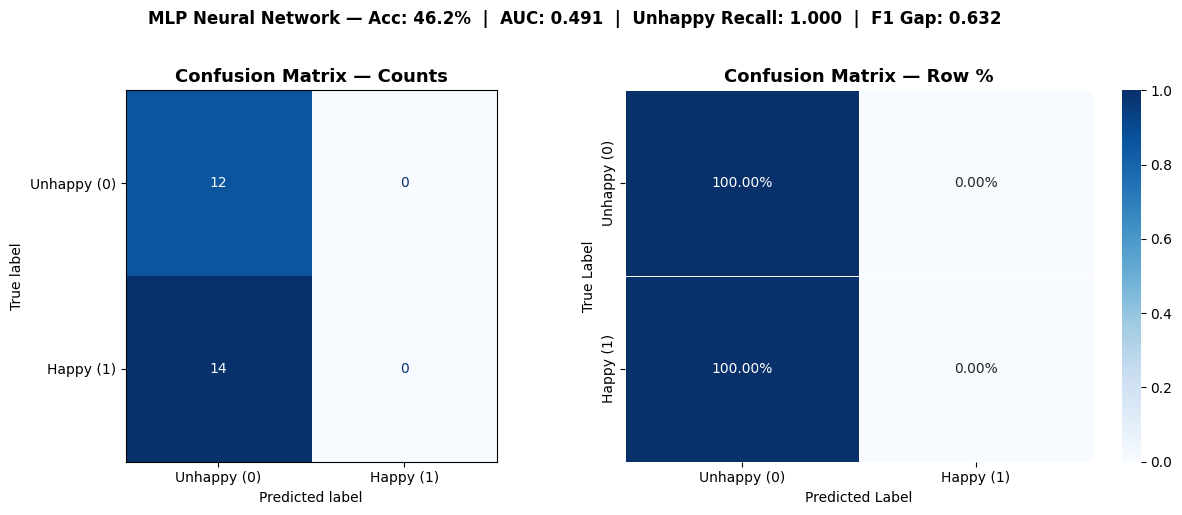


── Confusion Matrix Breakdown ──
True  Negative (TN) : 12  → Correctly predicted Unhappy
False Positive (FP) : 0  → Unhappy predicted as Happy  ← Type I error
False Negative (FN) : 14  → Happy predicted as Unhappy  ← Type II error
True  Positive (TP) : 0  → Correctly predicted Happy

Recall  (Unhappy)   : 1.000  — of all actual Unhappy, % caught  ← primary focus
Precision (Happy)   : nan  — of all 'Happy' predictions, % correct
Recall    (Happy)   : 0.000  — of all actual Happy, % caught


C:\Users\divye\AppData\Local\Temp\ipykernel_70620\1031705358.py:241: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Precision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")


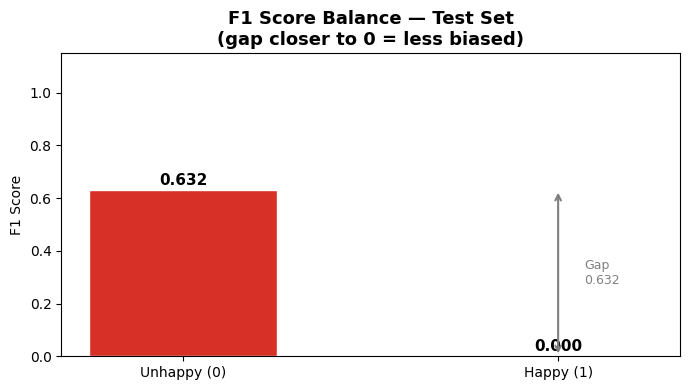

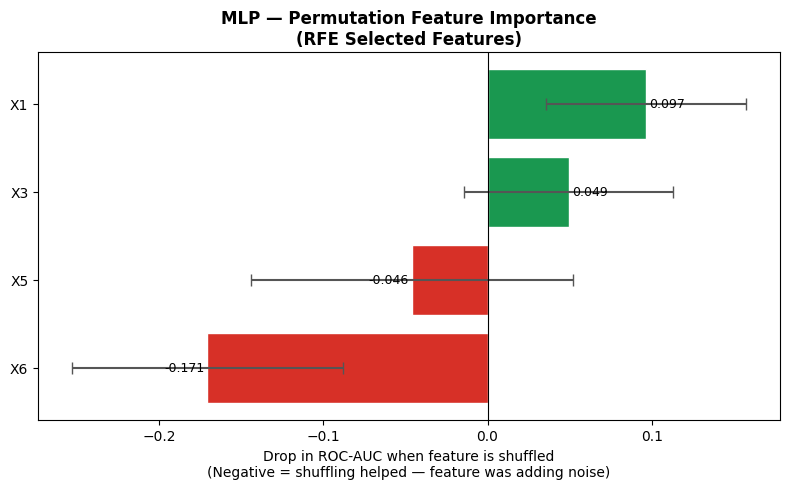

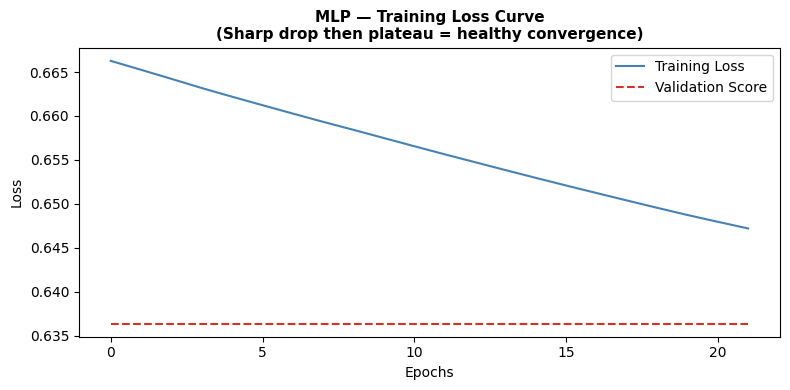


Total epochs trained : 22
Final training loss  : 0.6472


In [7]:
# ── MLP (Neural Network) │ No SMOTE │ RFE Feature Selection │ Unhappy Recall + Balanced F1 ──

# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']   # all 6 — RFE will decide

model_df = df.copy()

# Feature Engineering (all 6 base features)
model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols

X = model_df[all_features]
y = model_df['Y']

# ── 2. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]}  rows")
print(f"Class dist (train) — Happy: {y_train.sum()}, Unhappy: {(y_train==0).sum()}")

# ── 3. Scale First — RFE on MLP needs scaled data ────────────────────────────
# Unlike tree models, MLP is distance-based — scaling is MANDATORY before RFE
# We fit the scaler on train only to avoid data leakage
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# ── 4. RFE Feature Selection ──────────────────────────────────────────────────
# MLP doesn't have feature_importances_, so we wrap it in an RFE-compatible
# estimator using a small fast MLP just for the ranking pass.
# class_weight via sample_weight replaces SMOTE — no oversampling needed.
#
# ── Soft class weighting — tunable ratio ─────────────────────────────────────
# 'balanced' = full inverse ratio → too aggressive, model predicts almost all Unhappy
# Instead we use a SOFT ratio: Unhappy gets UNHAPPY_WEIGHT, Happy gets 1.0
#
#   UNHAPPY_WEIGHT = 2.0  → Unhappy twice as important as Happy  (recommended start)
#   UNHAPPY_WEIGHT = 1.5  → gentler push toward Unhappy recall
#   UNHAPPY_WEIGHT = 3.0  → stronger push (use if recall still too low)
#
# Tune this single knob — higher = more Unhappy Recall, wider F1 gap
#                         lower  = more balanced F1,   lower Unhappy Recall
UNHAPPY_WEIGHT = 2.0   # ← adjust this to control the recall / balance trade-off

def soft_sample_weights(y, unhappy_weight=UNHAPPY_WEIGHT):
    """Assign UNHAPPY_WEIGHT to class 0, 1.0 to class 1."""
    return np.where(np.array(y) == 0, unhappy_weight, 1.0)

sample_weights_train = soft_sample_weights(y_train)

mlp_rfe_estimator = MLPClassifier(
    hidden_layer_sizes  = (16, 8),
    activation          = 'relu',
    solver              = 'adam',
    alpha               = 0.01,
    learning_rate       = 'adaptive',
    learning_rate_init  = 0.001,
    max_iter            = 300,
    early_stopping      = True,
    validation_fraction = 0.15,
    n_iter_no_change    = 20,
    random_state        = 42
)

# RFE uses coef_ or feature_importances_; MLP exposes neither natively.
# We use permutation importance as a proxy by wrapping predict in a scorer.
# Simpler approach: use a shallow MLP + permutation-based RFE via RFECV substitute.
# Here we use RFE with a LinearSVC proxy just for ranking, then train MLP on result.
# ── Ranking proxy: use permutation importance on a quick MLP fit ──────────────
# Step 1: fit a quick MLP to get permutation-based feature ranks
mlp_rfe_estimator.fit(X_train_sc, y_train, sample_weight=sample_weights_train)

perm_rank = permutation_importance(
    mlp_rfe_estimator,
    X_train_sc, y_train,
    n_repeats    = 10,
    random_state = 42,
    scoring      = 'roc_auc',
    n_jobs       = -1
)

# Rank features: highest importance = rank 1 (kept), lowest = eliminated
importance_vals  = perm_rank.importances_mean
feature_ranks    = len(all_features) + 1 - importance_vals.argsort().argsort()  # rank 1 = best
n_keep           = 4
keep_idx         = np.argsort(importance_vals)[::-1][:n_keep]   # top-4 by importance
elim_idx         = np.argsort(importance_vals)[::-1][n_keep:]

selected_features = [all_features[i] for i in keep_idx]
eliminated        = [all_features[i] for i in elim_idx]
support_mask      = np.zeros(len(all_features), dtype=bool)
support_mask[keep_idx] = True

print(f"\nTotal features before selection : {len(all_features)}")
print(f"\n── Permutation-based Feature Selection Results ──")
print(f"{'Feature':<25} {'Status':<15} {'Permutation Importance'}")
print("-" * 60)
for i, (feat, imp) in enumerate(zip(all_features, importance_vals)):
    status = "✓  KEPT" if support_mask[i] else "✗  ELIMINATED"
    print(f"{feat:<25} {status:<15} {imp:.4f}")

print(f"\nKept       ({len(selected_features)})  : {selected_features}")
print(f"Eliminated ({len(eliminated)})  : {eliminated}")

X_train_sel = X_train_sc[:, keep_idx]
X_test_sel  = X_test_sc[:, keep_idx]

# ── 5. Build Final MLP Model ──────────────────────────────────────────────────
# No SMOTE — class imbalance handled via sample_weight passed to .fit()
# Scaling already applied above (fit on train, transform both splits)
# Architecture: kept small — large networks overfit on small data
mlp_model = MLPClassifier(
    hidden_layer_sizes  = (16, 8),     # 2 hidden layers: 16 then 8 neurons
    activation          = 'relu',      # ReLU: fast, avoids vanishing gradient
    solver              = 'adam',      # adaptive gradient — best for small datasets
    alpha               = 0.01,        # L2 regularisation on weights
    learning_rate       = 'adaptive',  # reduces lr when loss stops improving
    learning_rate_init  = 0.001,       # starting learning rate
    max_iter            = 500,         # max training epochs
    early_stopping      = True,        # stops if val loss does not improve
    validation_fraction = 0.15,        # 15% of train used for early stopping check
    n_iter_no_change    = 20,          # stop after 20 epochs of no improvement
    random_state        = 42
)

# ── 6. Cross-Validation — Unhappy Recall + F1 balance as dual focus ──────────
cv_final = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_unhappy_recall = []
cv_happy_recall   = []
cv_unhappy_f1     = []
cv_happy_f1       = []
cv_auc_scores     = []

X_train_sel_arr = np.array(X_train_sel)
y_train_arr     = np.array(y_train)

for train_idx, val_idx in cv_final.split(X_train_sel_arr, y_train_arr):
    X_fold_tr,  X_fold_val = X_train_sel_arr[train_idx], X_train_sel_arr[val_idx]
    y_fold_tr,  y_fold_val = y_train_arr[train_idx],     y_train_arr[val_idx]

    # Compute soft sample weights for this fold's training rows
    sw_fold = soft_sample_weights(y_fold_tr)

    mlp_model.fit(X_fold_tr, y_fold_tr, sample_weight=sw_fold)

    y_val_pred      = mlp_model.predict(X_fold_val)
    y_val_pred_prob = mlp_model.predict_proba(X_fold_val)[:, 1]

    cv_unhappy_recall.append(recall_score(y_fold_val, y_val_pred, pos_label=0, zero_division=0))
    cv_happy_recall.append(recall_score(y_fold_val,   y_val_pred, pos_label=1, zero_division=0))
    cv_unhappy_f1.append(f1_score(y_fold_val,         y_val_pred, pos_label=0, zero_division=0))
    cv_happy_f1.append(f1_score(y_fold_val,           y_val_pred, pos_label=1, zero_division=0))
    cv_auc_scores.append(roc_auc_score(y_fold_val, y_val_pred_prob))

cv_f1_gaps = [abs(h - u) for h, u in zip(cv_happy_f1, cv_unhappy_f1)]

print(f"\n── Cross-Validation Results (50 folds) ──")
print(f"CV Unhappy Recall    : {np.mean(cv_unhappy_recall):.4f}  ± {np.std(cv_unhappy_recall):.4f}  ← primary focus")
print(f"CV Happy   Recall    : {np.mean(cv_happy_recall):.4f}  ± {np.std(cv_happy_recall):.4f}")
print(f"CV Unhappy F1        : {np.mean(cv_unhappy_f1):.4f}  ± {np.std(cv_unhappy_f1):.4f}")
print(f"CV Happy   F1        : {np.mean(cv_happy_f1):.4f}  ± {np.std(cv_happy_f1):.4f}")
print(f"CV F1 Gap |H - U|    : {np.mean(cv_f1_gaps):.4f}  ± {np.std(cv_f1_gaps):.4f}  ← lower = more balanced")
print(f"CV ROC-AUC           : {np.mean(cv_auc_scores):.4f}  ± {np.std(cv_auc_scores):.4f}")

# ── 7. Train on Full Training Set & Evaluate on Test Set ─────────────────────
sample_weights_full = soft_sample_weights(y_train)
mlp_model.fit(X_train_sel, y_train, sample_weight=sample_weights_full)

y_pred      = mlp_model.predict(X_test_sel)
y_pred_prob = mlp_model.predict_proba(X_test_sel)[:, 1]

test_acc        = accuracy_score(y_test, y_pred)
test_auc        = roc_auc_score(y_test, y_pred_prob)
unhappy_rec     = recall_score(y_test, y_pred,  pos_label=0)
happy_rec       = recall_score(y_test, y_pred,  pos_label=1)
f1_unhappy_test = f1_score(y_test, y_pred,      pos_label=0)
f1_happy_test   = f1_score(y_test, y_pred,      pos_label=1)
f1_gap_test     = abs(f1_happy_test - f1_unhappy_test)

print(f"\n── Test Set Results ──")
print(f"Test Accuracy         : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test ROC-AUC          : {test_auc:.4f}")
print(f"Unhappy Recall (Y=0)  : {unhappy_rec:.4f}  ← primary focus")
print(f"Happy   Recall (Y=1)  : {happy_rec:.4f}")
print(f"Unhappy F1     (Y=0)  : {f1_unhappy_test:.4f}")
print(f"Happy   F1     (Y=1)  : {f1_happy_test:.4f}")
print(f"F1 Gap |Happy-Unhappy|: {f1_gap_test:.4f}  ← lower = less biased  (target < 0.10)")
print(f"\nOverfit Gap (Test AUC - CV AUC): {test_auc - np.mean(cv_auc_scores):.4f}")
print("  → < 0.05 gap = good | > 0.10 gap = overfitting warning")

# ── 8. Classification Report ──────────────────────────────────────────────────
print(f"\n── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Unhappy (0)', 'Happy (1)']
))

# ── 9. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Unhappy (0)', 'Happy (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Unhappy (0)', 'Happy (1)'],
            yticklabels=['Unhappy (0)', 'Happy (1)'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row %', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

fig.suptitle(
    f'MLP Neural Network — Acc: {test_acc*100:.1f}%  |  AUC: {test_auc:.3f}  |  '
    f'Unhappy Recall: {unhappy_rec:.3f}  |  F1 Gap: {f1_gap_test:.3f}',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('PLOTS/mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 10. Reading the Confusion Matrix ─────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\n── Confusion Matrix Breakdown ──")
print(f"True  Negative (TN) : {tn}  → Correctly predicted Unhappy")
print(f"False Positive (FP) : {fp}  → Unhappy predicted as Happy  ← Type I error")
print(f"False Negative (FN) : {fn}  → Happy predicted as Unhappy  ← Type II error")
print(f"True  Positive (TP) : {tp}  → Correctly predicted Happy")
print(f"\nRecall  (Unhappy)   : {tn/(tn+fp):.3f}  — of all actual Unhappy, % caught  ← primary focus")
print(f"Precision (Happy)   : {tp/(tp+fp):.3f}  — of all 'Happy' predictions, % correct")
print(f"Recall    (Happy)   : {tp/(tp+fn):.3f}  — of all actual Happy, % caught")

# ── 11. F1 Balance Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
classes = ['Unhappy (0)', 'Happy (1)']
f1_vals = [f1_unhappy_test, f1_happy_test]
colors  = ['#d73027', '#1a9850']

bars = ax.bar(classes, f1_vals, color=colors, edgecolor='white', width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Balance — Test Set\n(gap closer to 0 = less biased)',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.annotate('', xy=(1, f1_happy_test), xytext=(1, f1_unhappy_test),
            arrowprops=dict(arrowstyle='<->', color='grey', lw=1.5))
ax.text(1.07, (f1_happy_test + f1_unhappy_test) / 2,
        f'Gap\n{f1_gap_test:.3f}', va='center', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('PLOTS/mlp_f1_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 12. Permutation Feature Importance (selected features only) ───────────────
# MLP has no built-in feature importance — permutation importance is the
# standard approach: shuffle one feature at a time and measure AUC drop
perm = permutation_importance(
    mlp_model,
    X_test_sel, y_test,
    n_repeats    = 30,
    random_state = 42,
    scoring      = 'roc_auc',
    n_jobs       = -1
)

perm_df = pd.DataFrame({
    'Feature'   : selected_features,
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(perm_df['Feature'], perm_df['Importance'],
                xerr=perm_df['Std'],
                color=['#d73027' if v < 0 else '#1a9850' for v in perm_df['Importance']],
                edgecolor='white',
                error_kw=dict(ecolor='#555', capsize=4))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Drop in ROC-AUC when feature is shuffled\n(Negative = shuffling helped — feature was adding noise)')
plt.title('MLP — Permutation Feature Importance\n(RFE Selected Features)',
          fontsize=12, fontweight='bold')
for bar, val in zip(bars, perm_df['Importance']):
    offset = 0.002 if val >= 0 else -0.002
    ha     = 'left'  if val >= 0 else 'right'
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('PLOTS/mlp_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 13. Loss Curve — watch the network learn ─────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, color='steelblue', linewidth=1.5, label='Training Loss')
if hasattr(mlp_model, 'validation_scores_'):
    plt.plot(mlp_model.validation_scores_, color='#d73027',
             linewidth=1.5, linestyle='--', label='Validation Score')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MLP — Training Loss Curve\n(Sharp drop then plateau = healthy convergence)',
          fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('PLOTS/mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal epochs trained : {mlp_model.n_iter_}")
print(f"Final training loss  : {mlp_model.loss_:.4f}")